Podgląd adaptacji neuronu do danych -- wnętrze sieci MLP
--------------------------------------------------------

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler

from neuron_plots import generate, showXy, plot_hidden_layer_heatmap
from neuron_plots import plot_mlp_heatmap

Wybór danych do inspekcji

In [2]:
def get_case(i_case):
    corners0 = [[(-2, -2), (-0.5, 2), 100, 0],
                [(0.5, -2), (2, 2), 100, 1]]
    
    corners1 = [[(-2, -2), (-1, 2), 100, 0],
                [(-1, -2), (2, -1), 100, 0],
                [(1, -1), (2, 2), 100, 0],
                [(-1, 1), (1, 2), 100, 0],
                [(-0.8, -0.8), (0.8, 0.8), 100, 1]]
    
    corners2 = [[(-2, -2), (-1, 2), 100, 0],
                [(-1, -2), (0, 2), 100, 1],
                [(0, -2), (1, 2), 100, 0],
                [(1, -2), (2, 2), 100, 1]]

    if i_case == 0:
        return generate(corners0)
    elif i_case == 1:
        return generate(corners1)
    elif i_case == 2:
        return generate(corners2)
    elif i_case == 3:
        return make_moons(n_samples=500, noise=0.2, random_state=42)
    elif i_case == 4:
        iris = load_iris(as_frame=True)
        X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
        y_iris = iris.target
        X_iris_scaled = StandardScaler().fit_transform(X_iris)
        return X_iris_scaled, y_iris
    elif i_case == 5:
        wine = load_wine(as_frame=True)
        X_wine = wine.data[["alcohol", "color_intensity"]].values
        y_wine = wine.target
        X_wine_scaled = StandardScaler().fit_transform(X_wine)
        return X_wine_scaled, y_wine
    elif i_case == 6:
        bc = load_breast_cancer(as_frame=True)
        X_bc = bc.data[["mean radius", "worst concave points"]].values
        y_bc = bc.target
        X_bc_scaled = StandardScaler().fit_transform(X_bc)
        return X_bc_scaled, y_bc
    elif i_case == 7:
        peng = (pd.read_csv("penguins.csv").dropna())
        X_peng = peng[["bill_length_mm", "bill_depth_mm"]].values
        y_peng = peng["species"].astype("category").cat.codes.values   # 0,1,2
        X_peng_scaled = StandardScaler().fit_transform(X_peng)
        return X_peng_scaled, y_peng

Zautomatyzowana wizualizacja - trening sieci MLP i podgląd aktywacji
na poszczególnych warstwach

In [3]:
def automate(i_case, ofname, hls, seed=0, plot_loss=False):
    X, y = get_case(i_case)
    showXy(X, y, finish=True, ofname=ofname)
    mlp = MLPClassifier(hidden_layer_sizes=hls, max_iter=500, random_state=seed)
    mlp.fit(X, y)
    plot_hidden_layer_heatmap(mlp, xlim=(-3, 3), ylim=(-3, 3), 
                              grid_resolution=200, X=X, yc=y, ofname=ofname)
    plot_mlp_heatmap(mlp, xlim=(-3, 3), ylim=(-3, 3), grid_resolution=200,
                     X=X, yc=y, ofname=ofname)
    if plot_loss:
        plt.figure()#figsize=(10, 6))
        plt.plot(mlp.loss_curve_, 'r-', lw=2)
        plt.ylabel('Błąd (loss)')
        plt.xlabel('Iteracje')
        plt.show()

Przykładowe uruchomienia - spróbuj różnych wartosci parametru seed 
np. automate(3, None, (10, 10), seed=42)

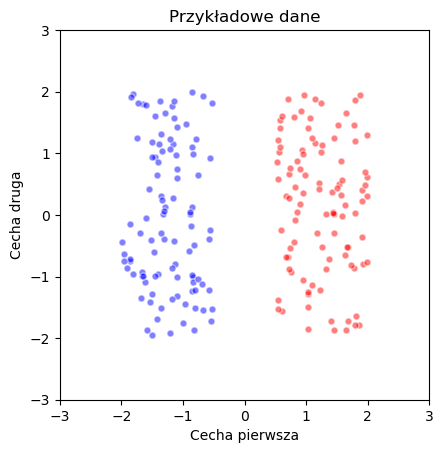

C:\bin\Anaconda3_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


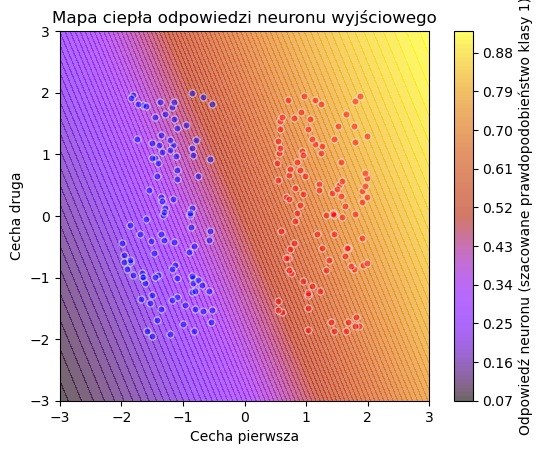

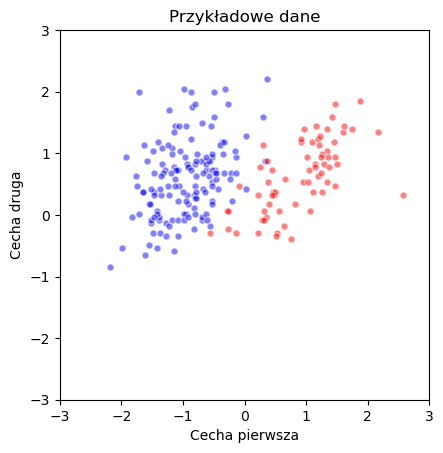

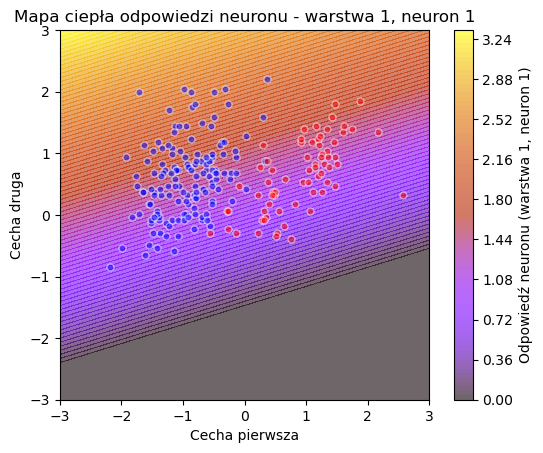

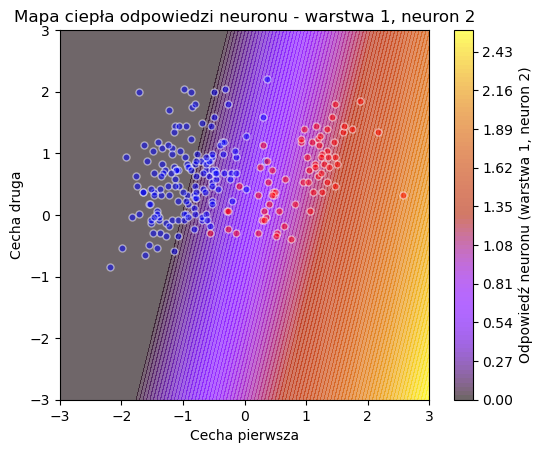

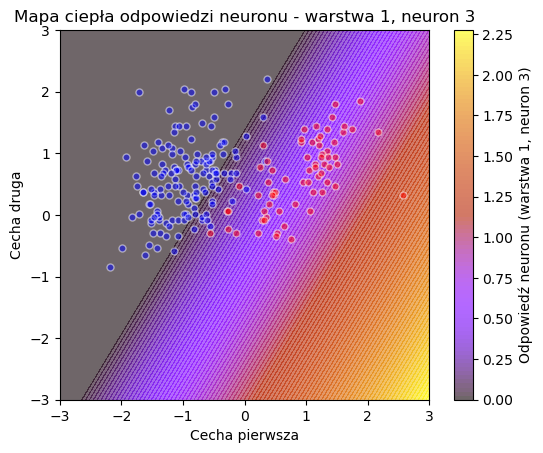

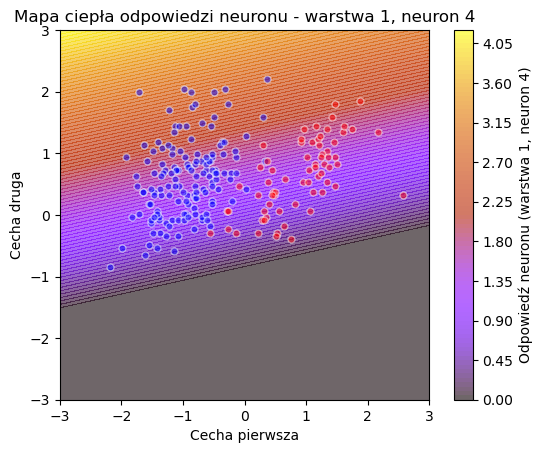

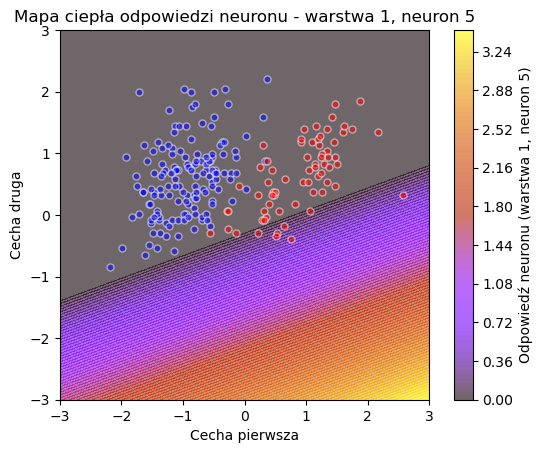

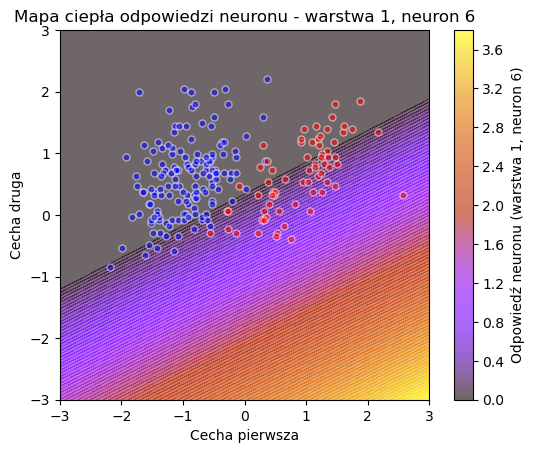

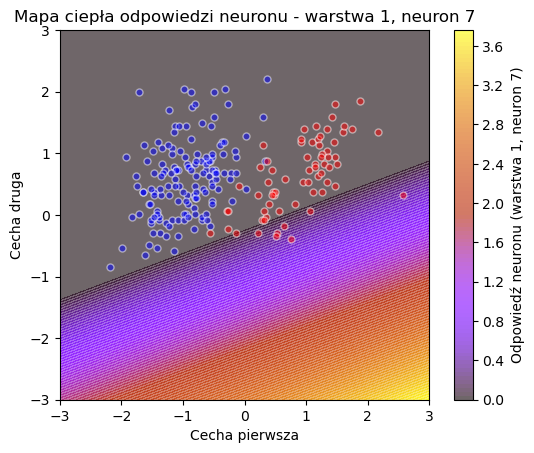

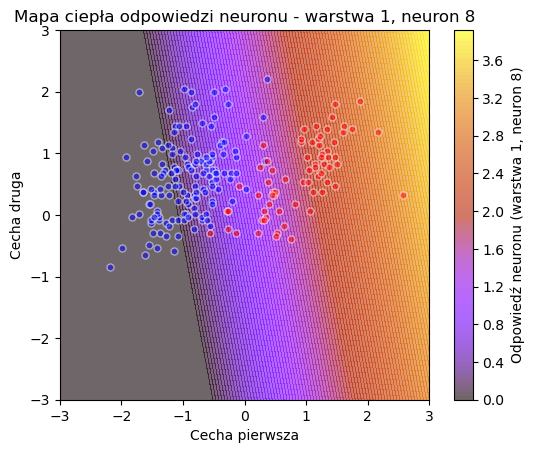

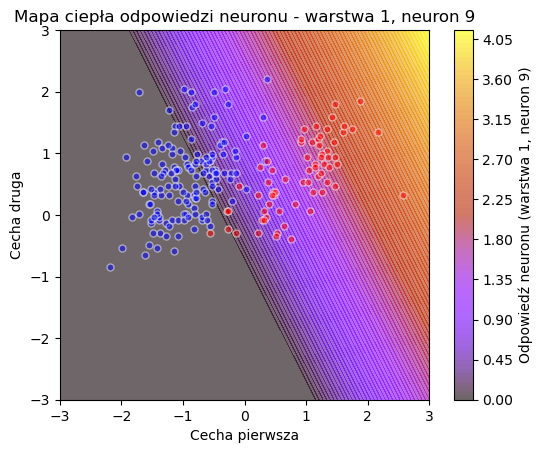

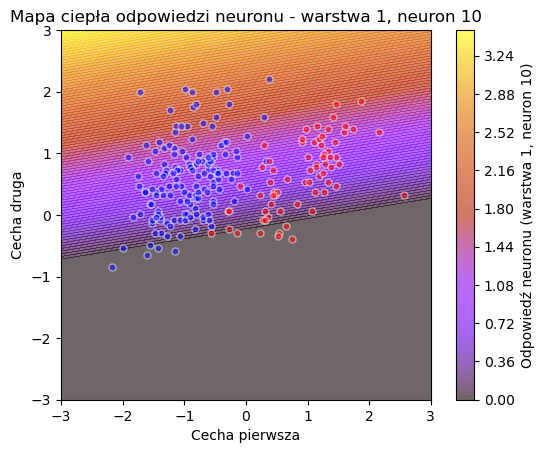

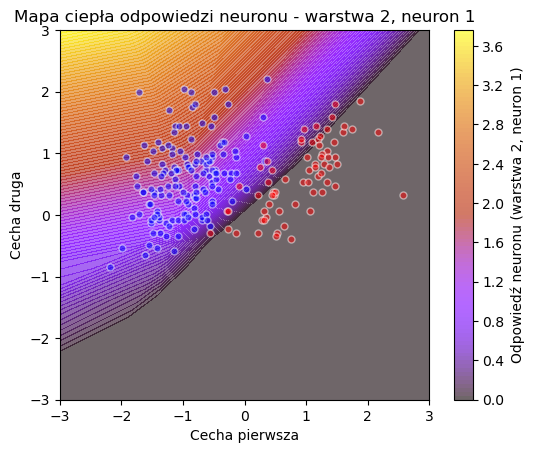

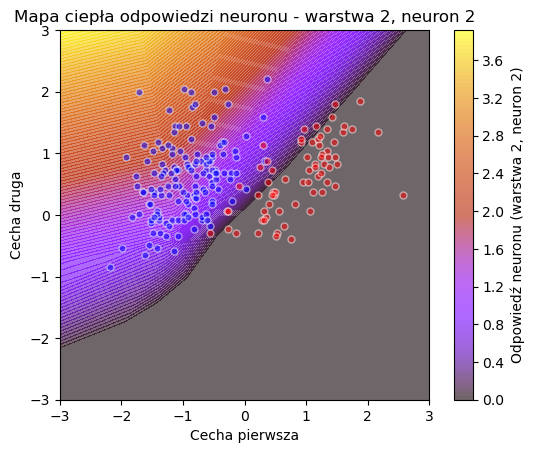

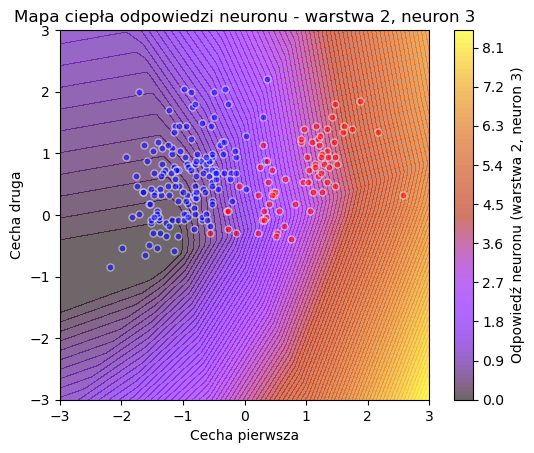

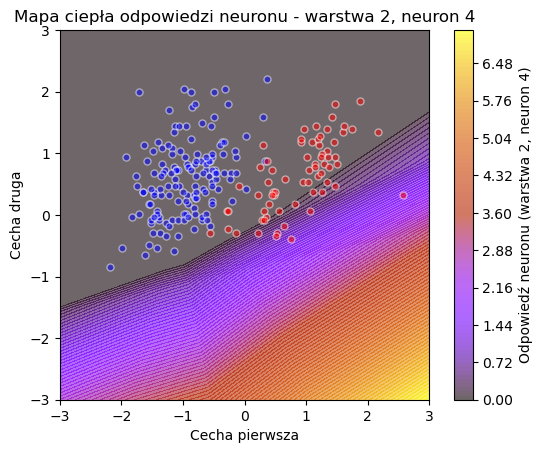

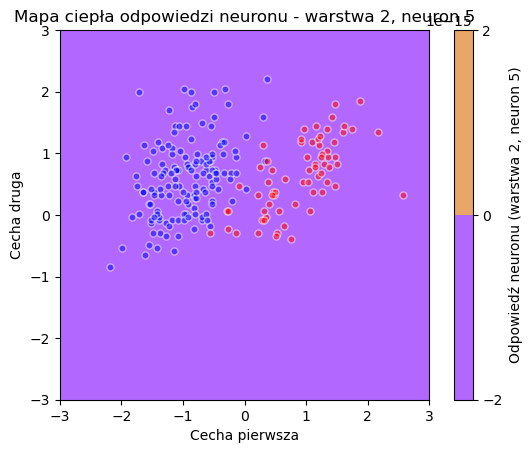

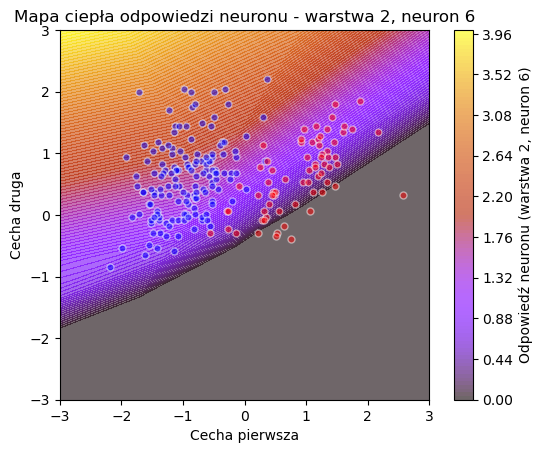

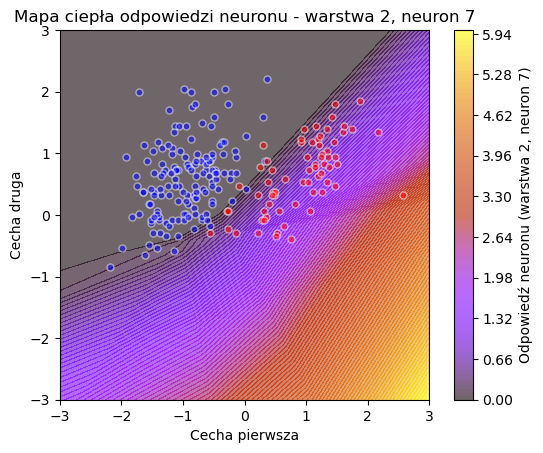

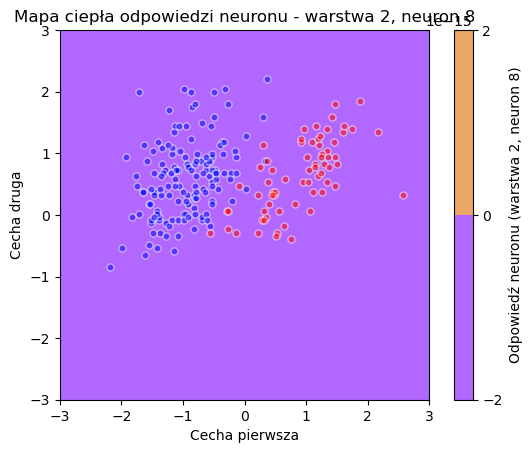

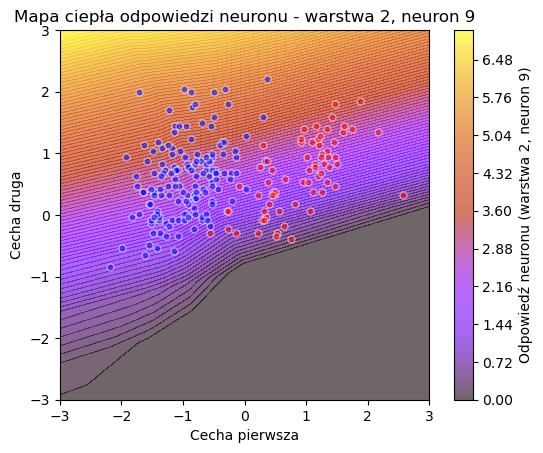

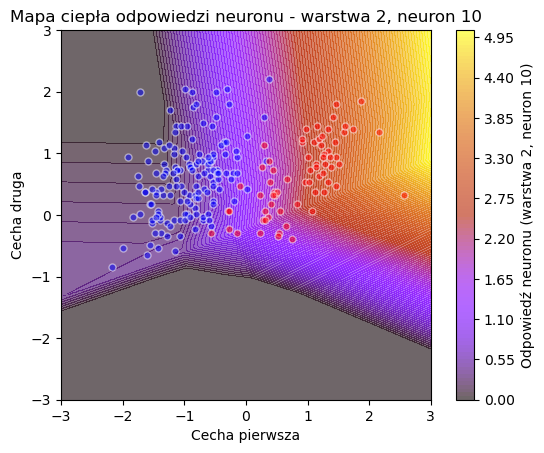

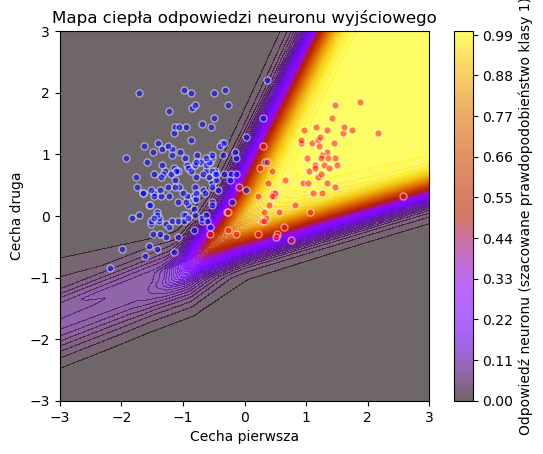

In [4]:
automate(0, None, ())
#automate(1, None, ())
# automate(1, None, ())
# automate(1, None, (4))
# automate(2, None, (4))
# automate(2, None, (5, 5))
# automate(3, None, (5, 5))
# automate(3, None, (10, 10))
# automate(4, None, (10, 10))
# automate(5, None, (10, 10))
# automate(6, None, (10, 10))
automate(7, None, (10, 10))
plt.show()